In [ ]:
# 1. IMPORTS

import toml

from PIL import Image

from google import genai

from pydantic import BaseModel, Field


print("✅ Imports successful")

✅ Imports successful


In [ ]:
# 2. GEMINI CONFIGURATION

import toml

# Load secrets.toml
secrets = toml.load("secrets.toml")


# Get API key
GEMINI_API_KEY = secrets.get("GEMINI_API_KEY")


if not GEMINI_API_KEY:
    raise ValueError(
        "❌ GEMINI_API_KEY was not found in secrets.toml"
    )


# Create Gemini client
client = genai.Client(
    api_key=GEMINI_API_KEY
)


# Current Gemini Flash-Lite model
GEMINI_MODEL = "gemini-3.5-flash-lite"


print("✅ Gemini configured successfully")
print("Model:", GEMINI_MODEL)

✅ Gemini configured successfully
Model: gemini-3.5-flash-lite


In [ ]:
# 3. WASTE ANALYSIS MODEL


class WasteAnalysisResult(BaseModel):

    waste_present: bool

    waste_type: str

    description: str

    estimated_volume: str

    hazard_score: int = Field(
        ge=1,
        le=10
    )

    visible_hazards: list[str]

    road_access: str

    recommended_vehicle: str

    confidence: float = Field(
        ge=0,
        le=1
    )


print("✅ Waste analysis model created")

✅ Waste analysis model created


In [ ]:
# 4. GEMINI PROMPT


WASTE_ANALYSIS_PROMPT = """
You are an AI assistant helping a municipal waste
management team inspect reported waste sites.

Analyze the uploaded image carefully.

Determine:

1. Whether waste is visible.

2. The main type of waste.

Examples:
- Household waste
- Plastic waste
- Construction waste
- Organic waste
- Electronic waste
- Mixed waste
- Other

3. Provide a short factual description.

4. Estimate the amount of waste:
- Small
- Medium
- Large

5. Give a hazard score from 1 to 10.

Consider only visible evidence such as:
- exposed waste
- sharp objects
- organic waste
- possible contamination
- blocked drainage
- environmental pollution
- dangerous materials

6. List visible hazards.

7. Estimate road access:
- Narrow
- Medium
- Wide

8. Recommend an appropriate municipal
waste collection vehicle.

Examples:
- Handcart
- Three-wheeler
- Mini truck
- Compactor truck
- JCB
- Other

9. Give your confidence from 0 to 1.

IMPORTANT:

Only use evidence visible in the image.

Do not invent objects.

If the image is unclear, lower the confidence.

If there is no waste, set waste_present to false.

Return ONLY the requested structured result.
"""

In [ ]:
# 5. IMAGE UPLOAD


import ipywidgets as widgets
from IPython.display import display


upload = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False
)


display(
    widgets.HTML(
        "<h3>♻️ Upload a Waste Image</h3>"
    )
)

display(upload)

HTML(value='<h3>♻️ Upload a Waste Image</h3>')

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

In [ ]:

# 6. GET UPLOADED IMAGE


if not upload.value:

    raise ValueError(
        "❌ No image uploaded. Please upload an image first."
    )


# Get uploaded file

uploaded_file = upload.value[0]


file_name = uploaded_file["name"]


file_content = uploaded_file["content"]


# Save image

with open(
    file_name,
    "wb"
) as f:

    f.write(file_content)


print("✅ Image uploaded successfully")
print("File:", file_name)
print("Size:", len(file_content), "bytes")

✅ Image uploaded successfully
File: test_waste.png
Size: 1975831 bytes


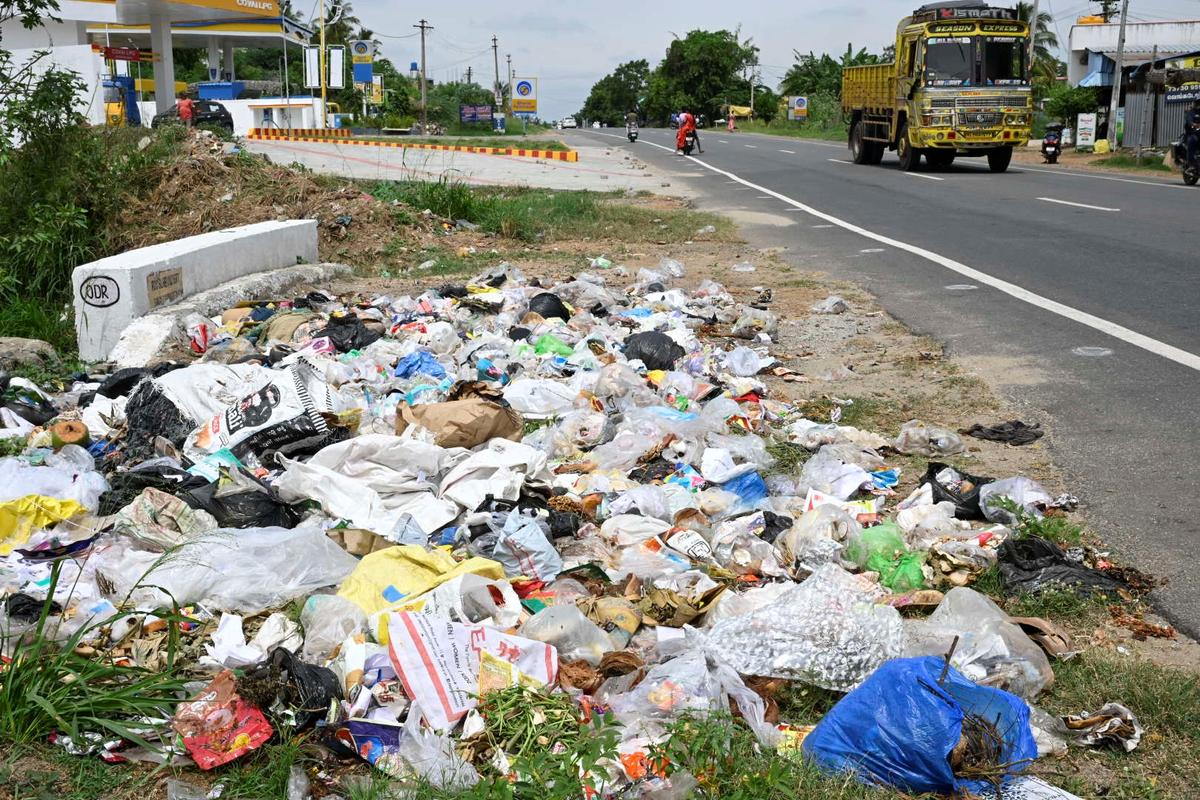

Image size: (1200, 800)


In [ ]:
# 7. DISPLAY IMAGE


image = Image.open(file_name)

display(image)

print("Image size:", image.size)

In [ ]:
# 8. GEMINI WASTE ANALYSIS

print("🔍 Sending image to Gemini...")
print("Please wait...\n")

try:

    response = client.models.generate_content(

        model=GEMINI_MODEL,

        contents=[
            WASTE_ANALYSIS_PROMPT,
            image
        ],

        config={
            "response_mime_type": "application/json",
            "response_schema": WasteAnalysisResult
        }
    )

    print("✅ Gemini response received")

    print("\nRaw response:")
    print(response.text)


except Exception as e:

    print("❌ Gemini request failed")
    print()
    print(type(e).__name__)
    print(e)

    raise

🔍 Sending image to Gemini...
Please wait...

✅ Gemini response received

Raw response:
{
  "waste_present": true,
  "waste_type": "Mixed waste",
  "description": "Large accumulation of mixed waste including plastic bags, wrappers, organic matter, and general refuse scattered along the roadside near a highway.",
  "estimated_volume": "Large",
  "hazard_score": 6,
  "visible_hazards": [
    "exposed waste",
    "environmental pollution",
    "organic waste"
  ],
  "road_access": "Wide",
  "recommended_vehicle": "Compactor truck",
  "confidence": 0.95
}
